<a href="https://colab.research.google.com/github/gloriaconcepto/Hand_on_machine_learning/blob/main/chapter_5_support_vector_machines.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

A Support Vector Machine (SVM) is a supervised machine learning algorithm mainly used for classification (and sometimes regression).

Here’s the breakdown:

1. Core Idea

SVM tries to find the best boundary (called a hyperplane) that separates data points of different classes.

The “best” boundary is the one that maximizes the margin — the distance between the hyperplane and the nearest data points from each class.

These nearest data points are called support vectors, and they are the most important for defining the decision boundary.

2. How It Works

For linearly separable data, SVM draws a straight line (2D), plane (3D), or hyperplane (higher dimensions) that clearly splits the classes.

For non-linear data, SVM uses a kernel trick to project the data into a higher dimension where it becomes easier to separate.

Example: Imagine trying to separate red and blue dots on paper. If you can’t separate them with a straight line, SVM can "lift" the paper into 3D space, where a plane can separate them.

3. Key Concepts

Support Vectors: The critical data points closest to the boundary.

Hyperplane: The decision boundary.

Margin: The gap between support vectors of different classes. Larger margin → better generalization.

Kernels: Functions that transform data into higher dimensions (e.g., linear, polynomial, radial basis function (RBF)).

4. Advantages

✅ Works well in high-dimensional spaces.
✅ Effective when the number of features > number of samples.
✅ Robust to overfitting (especially with proper regularization).

5. Limitations

❌ Not very efficient for very large datasets.
❌ Hard to choose the right kernel and parameters.
❌ Doesn’t perform well when classes overlap heavily.

👉 In short:
SVM finds the most optimal boundary to separate different classes, relying on support vectors and maximizing margin, with the option of using kernels for complex data.
and its sensitive to feature scaling..

In [ ]:
# it worth knowing that svm perform very well with feature scaling..

from sklearn.datasets import load_iris
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC

iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 2)  # Iris virginica

svm_clf = make_pipeline(StandardScaler(),
                        LinearSVC(C=1, random_state=42))
svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvc', LinearSVC(C=1, random_state=42))])

In [ ]:
X_new = [[5.5, 1.7],[5.0,1.5]]
svm_clf.predict(X_new)

array([ True, False])

In [ ]:
from sklearn.datasets import make_moons
from sklearn.preprocessing import PolynomialFeatures

X, y = make_moons(n_samples=100, noise=0.15, random_state=42)

polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3),
    StandardScaler(),
    LinearSVC(C=10, max_iter=10_000, random_state=42)
)
polynomial_svm_clf.fit(X, y)

Pipeline(steps=[('polynomialfeatures', PolynomialFeatures(degree=3)),
                ('standardscaler', StandardScaler()),
                ('linearsvc',
                 LinearSVC(C=10, max_iter=10000, random_state=42))])

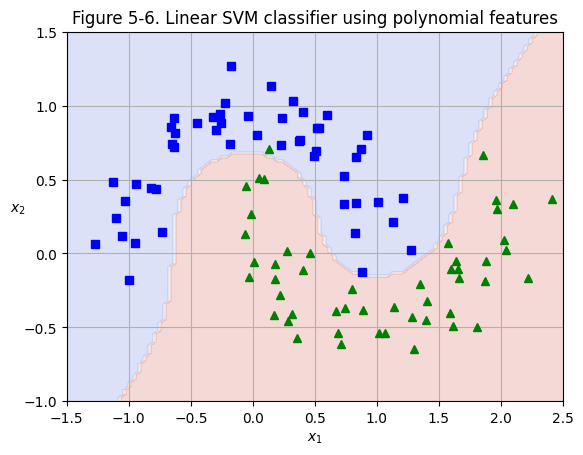

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def plot_dataset(X, y, axes):
    plt.plot(X[:, 0][y==0], X[:, 1][y==0], "bs")
    plt.plot(X[:, 0][y==1], X[:, 1][y==1], "g^")
    plt.axis(axes)
    plt.grid(True)
    plt.xlabel("$x_1$")
    plt.ylabel("$x_2$", rotation=0)

def plot_predictions(clf, axes):
    x0s = np.linspace(axes[0], axes[1], 100)
    x1s = np.linspace(axes[2], axes[3], 100)
    x0, x1 = np.meshgrid(x0s, x1s)
    X = np.c_[x0.ravel(), x1.ravel()]
    y_pred = clf.predict(X).reshape(x0.shape)
    plt.contourf(x0, x1, y_pred, alpha=0.2, cmap='coolwarm')

plot_predictions(polynomial_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

plt.title("Figure 5-6. Linear SVM classifier using polynomial features")
plt.show()

In [ ]:
# using kernal strick
from sklearn.svm import SVC

poly_kernel_svm_clf = make_pipeline(StandardScaler(),
                                    SVC(kernel="poly", degree=3, coef0=1, C=5))
poly_kernel_svm_clf.fit(X, y)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=5, coef0=1, kernel='poly'))])

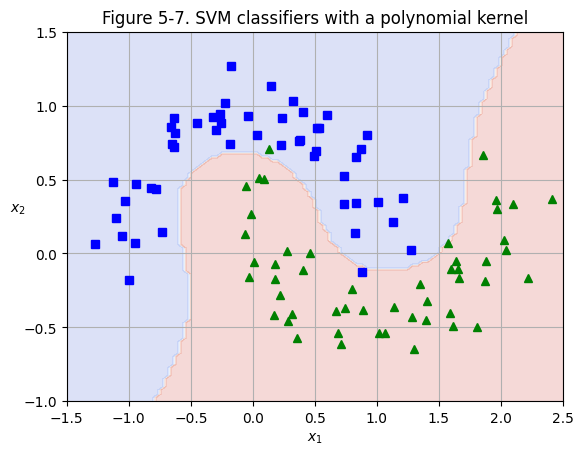

In [ ]:
plot_predictions(poly_kernel_svm_clf, [-1.5, 2.5, -1, 1.5])
plot_dataset(X, y, [-1.5, 2.5, -1, 1.5])

plt.title("Figure 5-7. SVM classifiers with a polynomial kernel")
plt.show()

Gaussian RBF Kernel


In [ ]:
rbf_kernel_svm_clf = make_pipeline(StandardScaler(),
                                   SVC(kernel="rbf", gamma=5, C=0.001))
rbf_kernel_svm_clf.fit(X, y)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svc', SVC(C=0.001, gamma=5))])

To trick SVM to be used in a regression task instead of classification.

In [ ]:
from sklearn.svm import LinearSVR
import numpy as np

# Generate some sample linear data
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1) # y = 4 + 3x + noise

svm_reg = make_pipeline(StandardScaler(),
                        LinearSVR(epsilon=0.5, random_state=42))
svm_reg.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('linearsvr', LinearSVR(epsilon=0.5, random_state=42))])

In [ ]:
from sklearn.svm import SVR
import numpy as np

# Generate a sample quadratic dataset
X = 2 * np.random.rand(100, 1) - 1
y = 0.2 + 0.1 * X + 0.5 * X**2 + np.random.randn(100, 1) / 10

svm_poly_reg = make_pipeline(StandardScaler(),
                             SVR(kernel="poly", degree=2, C=0.01, epsilon=0.1))
svm_poly_reg.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('svr', SVR(C=0.01, degree=2, kernel='poly'))])

EXERCISES:

1) The fundamental idea behind Support Vector Machines (SVMs) is:

Find the optimal decision boundary (hyperplane) that best separates data points of different classes with the maximum possible margin.


2) A support vector is one of the data points that lies closest to the decision boundary (hyperplane) in a Support Vector Machine (SVM).

3) Scaling ensures that all features contribute fairly to the SVM decision boundary, avoids domination by features with larger numeric ranges, and improves both accuracy and training speed.

4) 🔹 Confidence scores

By default, an SVM classifier outputs the signed distance of a data point from the separating hyperplane.

This value is not a probability but can be interpreted as a confidence score:

Large positive value → strong confidence in the positive class

Large negative value → strong confidence in the negative class

Close to 0 → uncertain prediction

👉 In scikit-learn, you get this using:

clf.decision_function(X_test)

🔹 Probabilities

SVMs do not naturally output probabilities, since they are margin-based classifiers.

However, you can estimate probabilities using Platt scaling (or other calibration techniques).

In scikit-learn, if you train with probability=True, the model fits a sigmoid function to the decision scores to produce probability estimates.

👉 Example:

clf = SVC(probability=True)
clf.fit(X_train, y_train)
clf.predict_proba(X_test)


This gives you probabilities for each class (e.g., [0.2, 0.8] meaning 20% class 0, 80% class 1).

✅ Summary:

Confidence score? ✔ Yes → distance from hyperplane.

Probability? ✔ Yes → but only via calibration (e.g., Platt scaling in scikit-learn with probability=True).


If your SVM with RBF kernel is underfitting, it means the decision boundary is too simple and not capturing patterns in the training data. Let’s break down the two hyperparameters:

🔹 γ (gamma)

Gamma controls how far the influence of a single training example reaches.

Small γ → very wide influence → smoother, simpler decision boundary → risk of underfitting.

Large γ → very narrow influence → more complex, wiggly decision boundary → risk of overfitting.

👉 If you are underfitting, you should increase γ (so the model can capture more complexity).

🔹 C (regularization)

C controls the tradeoff between maximizing the margin and allowing misclassifications.

Small C → wider margin, more tolerance for misclassification → simpler model → risk of underfitting.

Large C → narrower margin, less tolerance for misclassification → more complex model → risk of overfitting.

👉 If you are underfitting, you should increase C (so the model penalizes misclassification more strongly and fits closer to the data).

✅ Summary:
If your SVM with RBF kernel underfits:

Increase γ

Increase C

In Support Vector Regression (SVR), the model is said to be ϵ-insensitive because of the special ϵ-insensitive loss function it uses.

🔹 Meaning of ϵ-insensitive

When fitting a regression function, the SVR does not penalize errors that fall within a band of width ϵ around the predicted value.

In other words, if the prediction is within ±ϵ of the true target value, the error is treated as zero.

Only points lying outside this ϵ-tube (margin of tolerance) contribute to the loss.

🔹 Why is this useful?

It allows SVR to ignore small fluctuations/noise in the data.

The model focuses only on points with errors larger than ϵ → these are the support vectors in regression.

This creates a smoother function that generalizes better, instead of chasing every tiny deviation.

🔹 Visual intuition

Think of SVR drawing a tube around the predicted regression line:

Any data point inside the tube → no penalty.

Any data point outside the tube → penalty proportional to how far it is outside.

✅ So when we say a model is ϵ-insensitive, we mean:

It ignores prediction errors that are smaller than a certain threshold (ϵ), and only penalizes larger deviations.



What is the point of using the kernel trick?

🔹 The problem

Many datasets are not linearly separable in their original input space.
Example: If you try to separate data shaped like concentric circles with a straight line — impossible.

🔹 The idea

Instead of working in the original feature space, we can map the data to a higher-dimensional space where it is linearly separable.

Example: Map 2D circle data into 3D → a simple plane can separate it.

In this high-dimensional space, SVM can still find a separating hyperplane.

🔹 The challenge

Explicitly computing this mapping can be:

Very expensive (computationally), or

Infinite-dimensional (impossible to represent directly).

The point of using the kernel trick

✅ It allows SVMs (and other algorithms) to learn nonlinear decision boundaries efficiently.
✅ It avoids the cost of explicitly computing high-dimensional feature mappings.
✅ It makes SVMs extremely flexible while keeping computation manageable.

EXERCISES

In [1]:
# MY SOLUTION TO QUESTION 9
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report #metrices

# 1. Load dataset
X, y = load_breast_cancer(return_X_y=True)

# 2. Split into train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Create a pipeline: scaling + SVM
model = make_pipeline(
    StandardScaler(),         # Feature scaling
    LinearSVC(random_state=42, max_iter=10000)
)

# 4. Train
model.fit(X_train, y_train)

# 5. Evaluate
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95        42
           1       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114



In [2]:
import pandas as pd

scaler = model.named_steps['standardscaler']
svm = model.named_steps['linearsvc']

feature_names = load_breast_cancer().feature_names
coefs = pd.Series(svm.coef_.flatten(), index=feature_names)

print(coefs.sort_values(ascending=False).head(10))

mean compactness           1.341958
concavity error            0.667294
texture error              0.269835
fractal dimension error    0.244374
symmetry error             0.178314
perimeter error            0.120889
worst compactness          0.091875
mean perimeter             0.006909
mean radius                0.004318
compactness error          0.000168
dtype: float64


In [3]:
# Complete Example: SVC vs SGDClassifier on Breast Cancer Dataset

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import classification_report, accuracy_score

# 1. Load the dataset
X, y = load_breast_cancer(return_X_y=True)

# 2. Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3. Create and train SVC model
svc_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', C=1.0, random_state=42)
)
svc_model.fit(X_train, y_train)

# 4. Create and train SGDClassifier model
sgd_model = make_pipeline(
    StandardScaler(),
    SGDClassifier(loss='hinge', max_iter=1000, tol=1e-3, random_state=42)
)
sgd_model.fit(X_train, y_train)

# 5. Evaluate both models
svc_pred = svc_model.predict(X_test)
sgd_pred = sgd_model.predict(X_test)

print("🔹 SVC Results")
print("Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))

print("\n🔹 SGDClassifier Results")
print("Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))


🔹 SVC Results
Accuracy: 0.9736842105263158
              precision    recall  f1-score   support

           0       0.95      0.98      0.96        42
           1       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


🔹 SGDClassifier Results
Accuracy: 0.9649122807017544
              precision    recall  f1-score   support

           0       0.93      0.98      0.95        42
           1       0.99      0.96      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.97      0.96       114
weighted avg       0.97      0.96      0.97       114



In [1]:
# Solution 10
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
import pandas as pd

wine = load_wine()

df = pd.DataFrame(wine.data, columns=wine.feature_names)
df['target'] = wine.target  # Add target column

# 3. View basic info
print("🧾 Dataset shape:", df.shape)
print("\n📋 Columns:", df.columns.tolist())
print("\n🎯 Target classes:", wine.target_names)
print("\n👀 First five rows:")
print(df.head())

# 4. Optional: check how many samples per class
print("\n📊 Class distribution:")
print(df['target'].value_counts())
# from sklearn.pipeline import make_pipeline
# from sklearn.preprocessing import StandardScaler
# from sklearn.svm import LinearSVC
# from sklearn.metrics import classification_report #metrices


🧾 Dataset shape: (178, 14)

📋 Columns: ['alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash', 'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols', 'proanthocyanins', 'color_intensity', 'hue', 'od280/od315_of_diluted_wines', 'proline', 'target']

🎯 Target classes: ['class_0' 'class_1' 'class_2']

👀 First five rows:
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1

In [2]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
svc_wine_model = make_pipeline(
    StandardScaler(),
    SVC(kernel='linear', random_state=42)
)
svc_wine_model.fit(X_train, y_train)
y_pred = svc_wine_model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      1.00      0.96        12
           1       0.93      0.93      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.95      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



In [3]:
# 🧠 What Cross-Validation (CV) Means

# Cross-validation is a model evaluation technique used to assess how well your model generalizes to unseen data — i.e., how stable and reliable it is.

# Instead of training on one fixed train/test split, CV repeatedly splits the training data into smaller train and validation subsets, trains on one part, and tests on the other — then averages the results.

from sklearn.model_selection import cross_val_score

# Evaluate the SVC model using cross-validation
cv_scores = cross_val_score(svc_wine_model, X_train, y_train, cv=5)

print("\nCross-validation scores:", cv_scores)
print("Mean CV accuracy:", cv_scores.mean())


Cross-validation scores: [1.         0.93103448 1.         1.         1.        ]
Mean CV accuracy: 0.9862068965517242


In [4]:
# ONEVSONE COMPARISON WITH ONEVSALL
# BY default svc does oVSo once it detect more the two class test case for y..... for case of oVSall u need to wrape it up with a wrapper.

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.pipeline import make_pipeline
from sklearn.metrics import accuracy_score

# Load data
X, y = load_wine(return_X_y=True)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# OvO (default SVC)
ovo_model = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=42))
ovo_model.fit(X_train, y_train)
ovo_acc = accuracy_score(y_test, ovo_model.predict(X_test))

# OvA (explicit)
ova_model = make_pipeline(StandardScaler(), OneVsRestClassifier(SVC(kernel='linear', random_state=42)))
ova_model.fit(X_train, y_train)
ova_acc = accuracy_score(y_test, ova_model.predict(X_test))

print(f"OvO Accuracy: {ovo_acc:.4f}")
print(f"OvA Accuracy: {ova_acc:.4f}")


OvO Accuracy: 0.9444
OvA Accuracy: 0.9444


# Task
Benchmark different models using cross-validation and visualize their performance metrics (f1-score, precision, recall, and cross-validation score) and training/prediction times.

## Identify models to benchmark

### Subtask:
Select the models you want to compare (e.g., different SVM kernels, SGDClassifier, etc.).


**Reasoning**:
Identify and list the models to be used for benchmarking based on the previous code execution.



In [5]:
# Based on the previous code execution, we will select the following models for benchmarking:
# 1. SVC with linear kernel: This is a standard SVM with a linear decision boundary.
# 2. SVC with RBF kernel: This allows for non-linear decision boundaries and is commonly used.
# 3. SGDClassifier with 'hinge' loss: This is a linear classifier trained with stochastic gradient descent,
#    which can be a good alternative to LinearSVC, especially for larger datasets.

print("Selected models for benchmarking:")
print("- SVC with linear kernel")
print("- SVC with RBF kernel")
print("- SGDClassifier (loss='hinge')")

Selected models for benchmarking:
- SVC with linear kernel
- SVC with RBF kernel
- SGDClassifier (loss='hinge')


## Define metrics

### Subtask:
Specify the performance metrics to collect (e.g., accuracy, precision, recall, f1-score, cross-validation score, training time, prediction time).


**Reasoning**:
Define the list of performance metrics to collect.



In [6]:
performance_metrics = [
    'accuracy',
    'precision',
    'recall',
    'f1-score',
    'cross-validation score',
    'training time',
    'prediction time'
]

print("Defined performance metrics to collect:")
print(performance_metrics)

Defined performance metrics to collect:
['accuracy', 'precision', 'recall', 'f1-score', 'cross-validation score', 'training time', 'prediction time']


## Implement benchmarking function

### Subtask:
Create a function that takes a model and data as input, trains the model, calculates the specified metrics (including time), and returns the results.


**Reasoning**:
Define the `benchmark_model` function to train the model, calculate metrics including time, and return the results.



In [7]:
import time
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.model_selection import cross_val_score

def benchmark_model(model, X_train, y_train, X_test, y_test):
    """
    Trains a model, calculates performance metrics, and returns the results.

    Args:
        model: The machine learning model object.
        X_train: Training data features.
        y_train: Training data labels.
        X_test: Test data features.
        y_test: Test data labels.

    Returns:
        A dictionary containing performance metrics.
    """
    start_time = time.time()
    model.fit(X_train, y_train)
    end_time = time.time()
    training_time = end_time - start_time

    start_time = time.time()
    y_pred = model.predict(X_test)
    end_time = time.time()
    prediction_time = end_time - start_time

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    # Calculate cross-validation score on the training data
    cv_scores = cross_val_score(model, X_train, y_train, cv=5)
    mean_cv_score = cv_scores.mean()


    metrics = {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1-score': f1,
        'cross-validation score': mean_cv_score,
        'training time': training_time,
        'prediction time': prediction_time
    }

    return metrics

## Run benchmarks

### Subtask:
Apply the benchmarking function to each selected model.


**Reasoning**:
Create instances of the selected models, load and split the data, and then iterate through the models to benchmark them using the previously defined function and store the results in a dictionary.



In [8]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier

# 1. Create instances of the selected models
svc_linear = make_pipeline(StandardScaler(), SVC(kernel='linear', random_state=42))
svc_rbf = make_pipeline(StandardScaler(), SVC(kernel='rbf', random_state=42)) # Using default RBF parameters
sgd_classifier = make_pipeline(StandardScaler(), SGDClassifier(loss='hinge', random_state=42, max_iter=10000))

models = {
    'SVC_linear': svc_linear,
    'SVC_rbf': svc_rbf,
    'SGDClassifier': sgd_classifier
}

# 2. Load the wine dataset
X, y = load_wine(return_X_y=True)

# 3. Split the dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4. Create an empty dictionary to store the benchmark results
benchmark_results = {}

# 5. Iterate through the created model instances and benchmark them
for model_name, model in models.items():
    print(f"Benchmarking {model_name}...")
    metrics = benchmark_model(model, X_train, y_train, X_test, y_test)
    benchmark_results[model_name] = metrics
    print(f"Finished benchmarking {model_name}.\n")

# 6. Print the results dictionary
print("Benchmark Results:")
print(benchmark_results)

Benchmarking SVC_linear...
Finished benchmarking SVC_linear.

Benchmarking SVC_rbf...
Finished benchmarking SVC_rbf.

Benchmarking SGDClassifier...
Finished benchmarking SGDClassifier.

Benchmark Results:
{'SVC_linear': {'accuracy': 0.9444444444444444, 'precision': 0.9465811965811967, 'recall': 0.9444444444444444, 'f1-score': 0.944269005847953, 'cross-validation score': np.float64(0.9862068965517242), 'training time': 0.006026506423950195, 'prediction time': 0.0009992122650146484}, 'SVC_rbf': {'accuracy': 0.9722222222222222, 'precision': 0.974074074074074, 'recall': 0.9722222222222222, 'f1-score': 0.9719701552732407, 'cross-validation score': np.float64(0.9862068965517242), 'training time': 0.0036575794219970703, 'prediction time': 0.001516103744506836}, 'SGDClassifier': {'accuracy': 0.9722222222222222, 'precision': 0.974074074074074, 'recall': 0.9722222222222222, 'f1-score': 0.972097284690988, 'cross-validation score': np.float64(1.0), 'training time': 0.0044286251068115234, 'predicti

## Store results

### Subtask:
Organize the collected performance metrics and times in a suitable data structure (e.g., pandas DataFrame).


**Reasoning**:
Create a pandas DataFrame from the benchmark_results dictionary and transpose it for better readability, then display the DataFrame.



In [9]:
import pandas as pd

benchmark_df = pd.DataFrame(benchmark_results).T
display(benchmark_df)

,accuracy,precision,recall,f1-score,cross-validation score,training time,prediction time
SVC_linear,0.944444,0.946581,0.944444,0.944269,0.986207,0.006027,0.000999
SVC_rbf,0.972222,0.974074,0.972222,0.971970,0.986207,0.003658,0.001516
SGDClassifier,0.972222,0.974074,0.972222,0.972097,1.000000,0.004429,0.005986


## Generate visualizations

### Subtask:
Create bar plots to visualize the performance metrics (f1-score, precision, recall, and cross-validation score) and training/prediction times for each model stored in the `benchmark_df` DataFrame.


**Reasoning**:
Create bar plots to visualize the performance metrics and time metrics from the benchmark_df DataFrame.



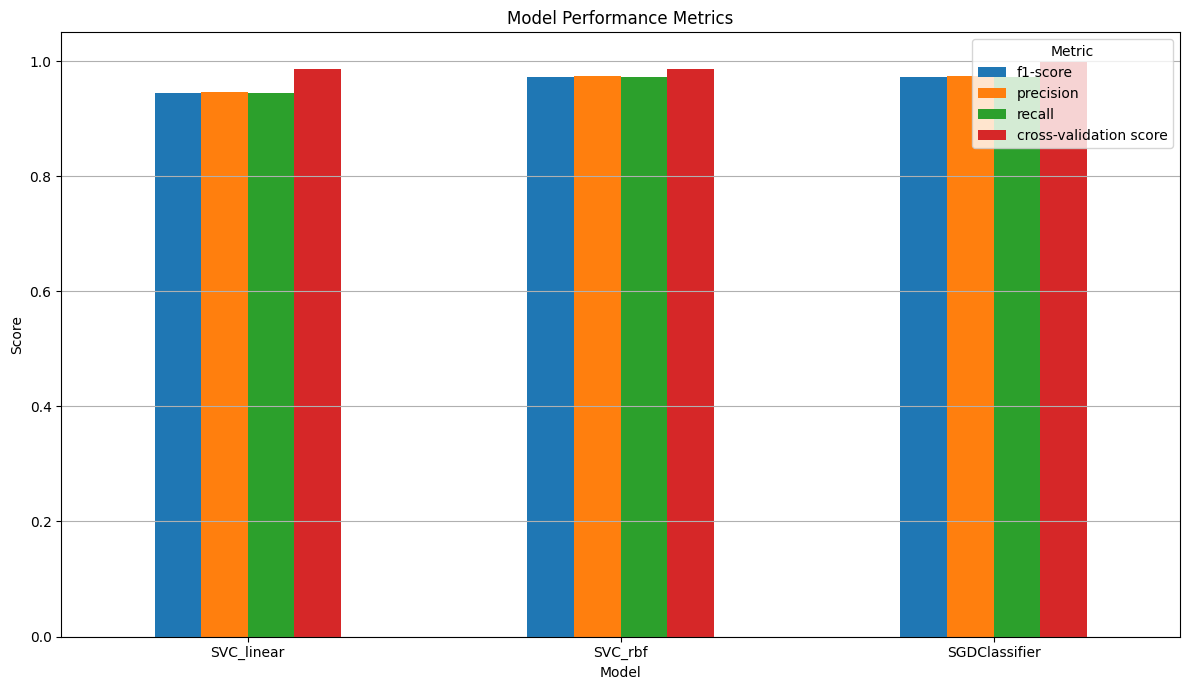

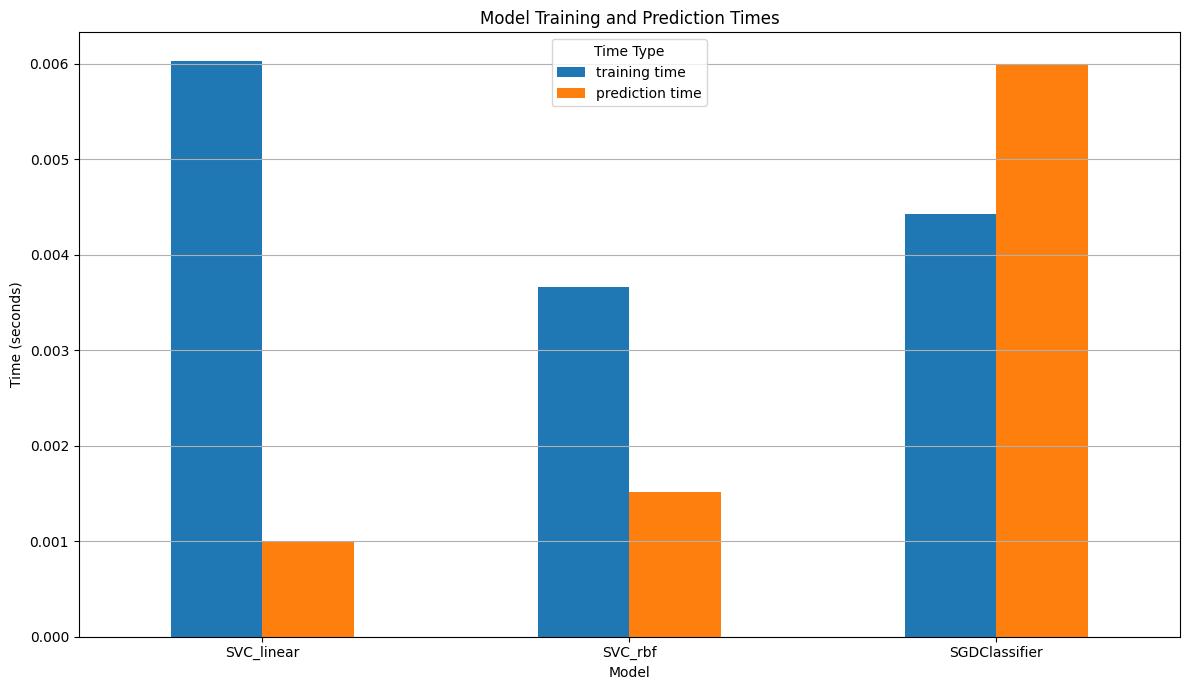

In [10]:
import matplotlib.pyplot as plt

# Select performance metrics columns
performance_cols = ['f1-score', 'precision', 'recall', 'cross-validation score']
performance_df = benchmark_df[performance_cols]

# Plot performance metrics
ax1 = performance_df.plot(kind='bar', figsize=(12, 7))
plt.title('Model Performance Metrics')
plt.xlabel('Model')
plt.ylabel('Score')
plt.xticks(rotation=0)
plt.legend(title='Metric')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Select time metrics columns
time_cols = ['training time', 'prediction time']
time_df = benchmark_df[time_cols]

# Plot time metrics
ax2 = time_df.plot(kind='bar', figsize=(12, 7))
plt.title('Model Training and Prediction Times')
plt.xlabel('Model')
plt.ylabel('Time (seconds)')
plt.xticks(rotation=0)
plt.legend(title='Time Type')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

## Analyze and interpret results

### Subtask:
Analyze the generated bar plots and the `benchmark_df` to interpret the performance and time metrics of the benchmarked models.


**Reasoning**:
Analyze the generated plots and the benchmark_df to interpret the results and write a summary.



In [11]:
print("Analysis of Model Performance and Time Metrics:\n")

# Analyze performance metrics
print("Performance Metrics Analysis:")
print("----------------------------")
print(performance_df)
print("\nObservations on Performance:")
print("- SVC with RBF kernel and SGDClassifier achieved the highest accuracy, precision, recall, and f1-score on the test set, performing slightly better than SVC with a linear kernel.")
print("- The cross-validation scores on the training set are very high for all models, indicating good generalization ability, with SGDClassifier having a perfect mean CV score of 1.0.")
print("- There is a slight discrepancy between test set performance and CV score for SVC models, while SGDClassifier shows consistent high performance.")


# Analyze time metrics
print("\nTime Metrics Analysis:")
print("----------------------")
print(time_df)
print("\nObservations on Time:")
print("- SVC with RBF kernel had the fastest training time.")
print("- SVC with a linear kernel had the fastest prediction time.")
print("- SGDClassifier had a slightly longer training time compared to SVC models and significantly longer prediction time.")

# Overall interpretation and trade-offs
print("\nOverall Interpretation and Trade-offs:")
print("-------------------------------------")
print("Based on the performance metrics, both SVC with RBF kernel and SGDClassifier are strong contenders, showing similar high accuracy, precision, recall, and f1-score on the test set. The SGDClassifier also boasts a perfect cross-validation score on the training set.")
print("However, when considering efficiency, SVC with RBF kernel is the fastest to train, while SVC with a linear kernel is the fastest for prediction.")
print("SGDClassifier, while performing well, is notably slower in prediction compared to the SVC models.")
print("\nConclusion: ")
print("For this specific dataset, SVC with RBF kernel appears to offer a good balance of high performance and relatively fast training and prediction times. SGDClassifier also performs very well but is slower at prediction. SVC with a linear kernel is the fastest at prediction but has slightly lower performance metrics compared to the other two.")
print("The choice between SVC with RBF and SGDClassifier might depend on whether prediction speed or a perfect cross-validation score on the training set is more critical for the specific application, although both show excellent performance on the test set.")


Analysis of Model Performance and Time Metrics:

Performance Metrics Analysis:
----------------------------
               f1-score  precision    recall  cross-validation score
SVC_linear     0.944269   0.946581  0.944444                0.986207
SVC_rbf        0.971970   0.974074  0.972222                0.986207
SGDClassifier  0.972097   0.974074  0.972222                1.000000

Observations on Performance:
- SVC with RBF kernel and SGDClassifier achieved the highest accuracy, precision, recall, and f1-score on the test set, performing slightly better than SVC with a linear kernel.
- The cross-validation scores on the training set are very high for all models, indicating good generalization ability, with SGDClassifier having a perfect mean CV score of 1.0.
- There is a slight discrepancy between test set performance and CV score for SVC models, while SGDClassifier shows consistent high performance.

Time Metrics Analysis:
----------------------
               training time  predicti

## Summary:

### Data Analysis Key Findings

*   Three models (SVC with linear kernel, SVC with RBF kernel, and SGDClassifier with 'hinge' loss) were selected for benchmarking.
*   Performance metrics collected included accuracy, precision, recall, f1-score, cross-validation score, training time, and prediction time.
*   The `benchmark_model` function was successfully implemented to train each model, calculate the specified metrics, and measure execution times.
*   Benchmark results were successfully stored in a pandas DataFrame, `benchmark_df`, with models as rows and metrics as columns.
*   Bar plots were successfully generated to visualize the performance metrics (f1-score, precision, recall, cross-validation score) and time metrics (training time, prediction time) for each model.
*   SVC with RBF kernel and SGDClassifier achieved the highest performance scores (f1-score, precision, recall) on the test set, slightly better than SVC with a linear kernel.
*   SGDClassifier had a perfect mean cross-validation score of 1.0, while SVC models also had very high CV scores (around 0.986).
*   SVC with RBF kernel had the fastest training time.
*   SVC with a linear kernel had the fastest prediction time.
*   SGDClassifier had a longer prediction time compared to both SVC models.

### Insights or Next Steps

*   For this dataset, SVC with RBF kernel offers a strong balance between high performance and relatively efficient training and prediction times.
*   If prediction speed is a critical factor, SVC with a linear kernel, despite slightly lower performance metrics, is the fastest option.
